In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcbG9pY2hcRG9jdW1lbnRzXFdvcmtcR2l0aHViXHF1YXJ0b1xweXRob25faWFfcXVhcnRvXG1vZHVsZXNcbW9kdWxlXzA3'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\zipimport.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\codecs.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\aliases.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\__init__.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\utf_8.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\cp1252.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\abc.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python

In [2]:
#| label: setup
import os
import json
import time
import logging
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import date, datetime
from typing import Literal
from dataclasses import dataclass

# Logging propre
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%H:%M:%S"
)
logger = logging.getLogger("techvolt")

print("✅ Environnement prêt")

✅ Environnement prêt


In [3]:
#| echo: false
# Chemin vers les ressources
DATA_DIR = Path("ressources_tp")

In [4]:
#| eval: false
DATA_DIR = Path("ressources_tp")

In [5]:
#| eval: false
# TODO: Étape 1.1

In [6]:
# Charger le corpus
with open(DATA_DIR / "knowledge_base.json", "r", encoding="utf-8") as f:
    corpus = json.load(f)

print(f"Nombre total de documents : {len(corpus)}")

# Répartition par catégorie
from collections import Counter
categories = Counter(doc["categorie"] for doc in corpus)
print(f"\nRépartition :")
for cat, n in sorted(categories.items()):
    print(f"  {cat:15s} : {n} docs")

# Premier document de chaque catégorie
print(f"\n--- Aperçu par catégorie ---")
vues = set()
for doc in corpus:
    if doc["categorie"] not in vues:
        vues.add(doc["categorie"])
        print(f"\n[{doc['categorie'].upper()}] {doc['titre']}")
        print(f"  {doc['contenu'][:150]}...")

Nombre total de documents : 26

Répartition :
  app             : 4 docs
  commercial      : 4 docs
  erreur          : 6 docs
  installation    : 5 docs
  sav             : 4 docs
  securite        : 3 docs

--- Aperçu par catégorie ---

[INSTALLATION] Prérequis électriques pour l'installation
  Pour installer une borne TechVolt résidentielle, votre installation électrique doit répondre à ces prérequis : compteur Linky ou équivalent, puissance...

[ERREUR] Code erreur E01 - Surchauffe
  Le code E01 signale une surchauffe de la borne (température interne > 65°C). Causes fréquentes : exposition prolongée au soleil, ventilation insuffisa...

[APP] Téléchargement et premiers pas avec l'app
  L'app TechVolt est disponible gratuitement sur l'App Store (iOS 14+) et Google Play (Android 8+). Premier lancement : créez un compte avec votre email...

[SAV] Coordonnées et horaires du SAV
  SAV TechVolt - coordonnées : Standard : 01 23 45 67 89 (du lundi au vendredi 8h-19h, samedi 9h-17h, fermé di

Longueur moyenne : 440 car. / 67 mots
Médiane           : 432 car.

Plus court : Coordonnées et horaires du SAV (333 car.)
Plus long  : Code erreur E04 - Court-circuit (CRITIQUE) (542 car.)


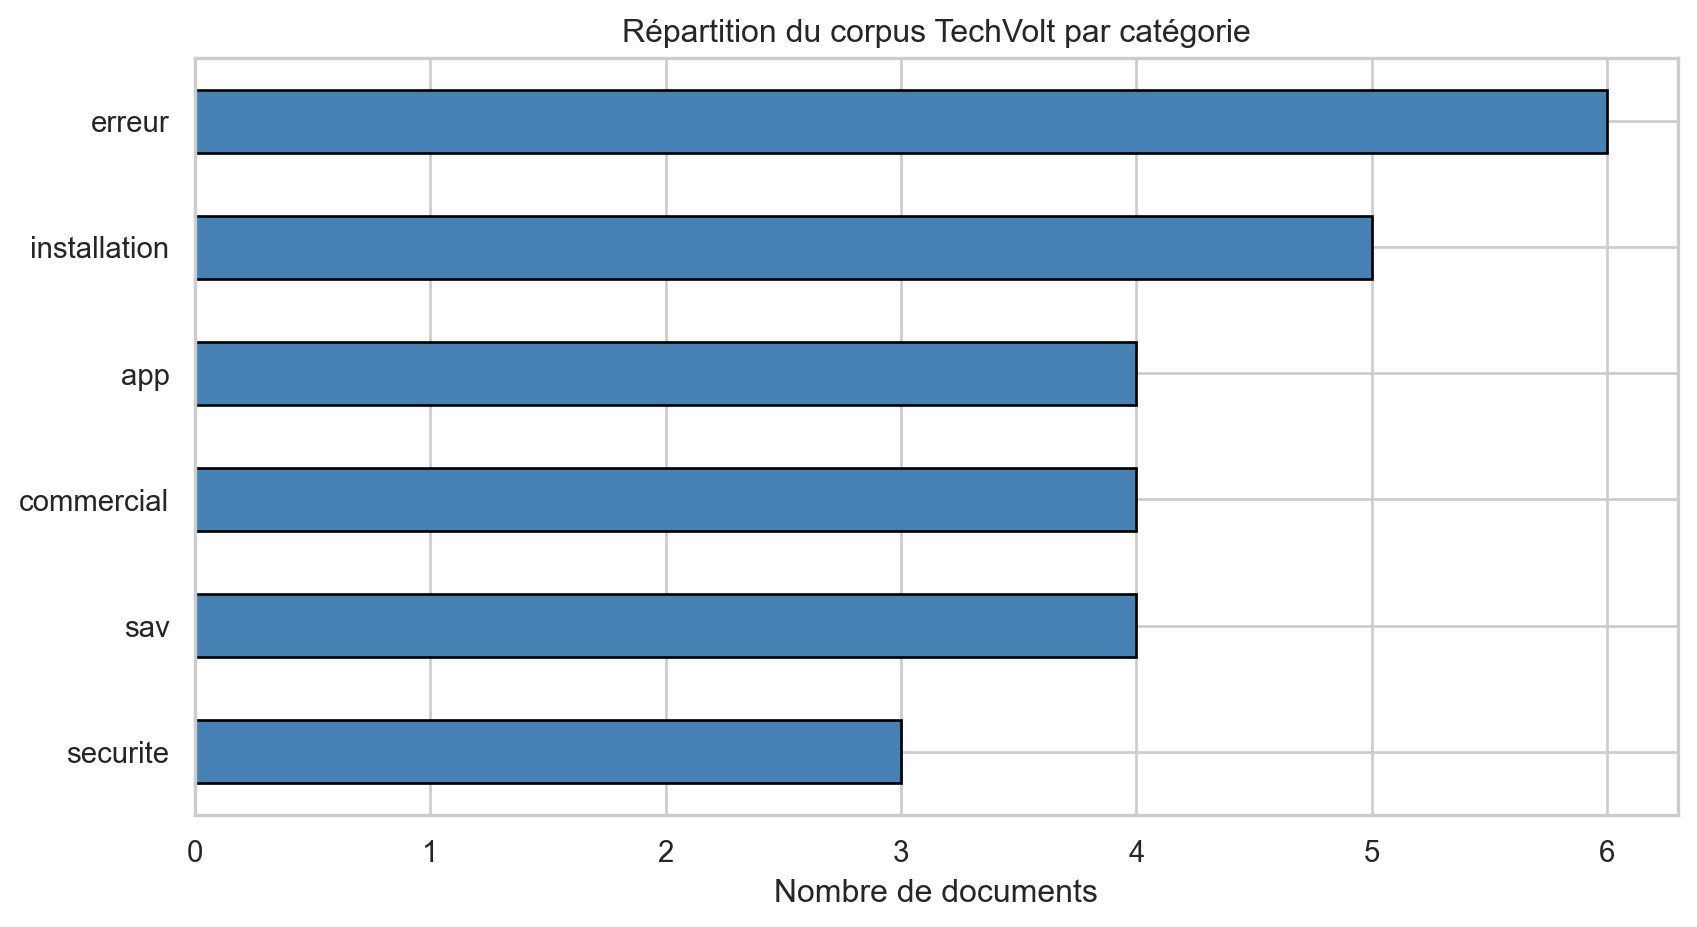

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Stats
longueurs_chars = [len(doc["contenu"]) for doc in corpus]
longueurs_mots = [len(doc["contenu"].split()) for doc in corpus]

print(f"Longueur moyenne : {np.mean(longueurs_chars):.0f} car. / {np.mean(longueurs_mots):.0f} mots")
print(f"Médiane           : {int(np.median(longueurs_chars))} car.")

# Min et max
idx_min = np.argmin(longueurs_chars)
idx_max = np.argmax(longueurs_chars)
print(f"\nPlus court : {corpus[idx_min]['titre']} ({longueurs_chars[idx_min]} car.)")
print(f"Plus long  : {corpus[idx_max]['titre']} ({longueurs_chars[idx_max]} car.)")

# Barplot catégories
fig, ax = plt.subplots(figsize=(9, 5))
cats_df = pd.Series(categories).sort_values()
cats_df.plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
ax.set_xlabel("Nombre de documents")
ax.set_title("Répartition du corpus TechVolt par catégorie")
plt.tight_layout()
plt.show()

In [8]:
#| eval: false
# TODO: Étape 2.1

In [9]:
#| eval: false
from sentence_transformers import SentenceTransformer

# Charger le modèle (1 fois, ~400 MB au 1er téléchargement)
logger.info("Chargement du modèle d'embeddings...")
modele_emb = SentenceTransformer("paraphrase-multilingual-mpnet-base-v2")

# Encoder en batch
t0 = time.time()
textes = [doc["contenu"] for doc in corpus]
embeddings = modele_emb.encode(textes, show_progress_bar=True)
duree = time.time() - t0

logger.info(f"Embeddings : {embeddings.shape} en {duree:.1f}s")

In [10]:
#| eval: false
import chromadb

# Client persistent
client_chroma = chromadb.PersistentClient(path="./chroma_techvolt")

# Supprimer si existe
try:
    client_chroma.delete_collection("techvolt_kb")
    logger.info("Ancienne collection supprimée")
except Exception:
    pass

# Créer avec métrique cosine
collection = client_chroma.create_collection(
    name="techvolt_kb",
    metadata={"hnsw:space": "cosine"}
)

# Ajouter tous les docs
collection.add(
    ids=[doc["id"] for doc in corpus],
    documents=[doc["contenu"] for doc in corpus],
    embeddings=embeddings.tolist(),
    metadatas=[
        {"titre": doc["titre"], "categorie": doc["categorie"]}
        for doc in corpus
    ],
)

logger.info(f"Indexé : {collection.count()} documents dans ChromaDB")

In [11]:
#| eval: false
def rechercher(question: str, k: int = 3, filtre_categorie: str = None) -> list:
    """Recherche sémantique dans ChromaDB."""
    q_emb = modele_emb.encode([question])[0].tolist()
    
    query_args = {"query_embeddings": [q_emb], "n_results": k}
    if filtre_categorie:
        query_args["where"] = {"categorie": filtre_categorie}
    
    results = collection.query(**query_args)
    
    # Formatter joliment
    passages = []
    for i in range(len(results["ids"][0])):
        passages.append({
            "id": results["ids"][0][i],
            "titre": results["metadatas"][0][i]["titre"],
            "contenu": results["documents"][0][i],
            "categorie": results["metadatas"][0][i]["categorie"],
            "distance": results["distances"][0][i],
        })
    return passages

# Tests
questions_test = [
    ("Comment installer ma borne ?", None),
    ("C'est quoi le code E04 ?", None),
    ("Combien coûte l'abonnement ?", "commercial"),
]

for q, filtre in questions_test:
    print(f"\n❓ {q}" + (f" [filtre={filtre}]" if filtre else ""))
    passages = rechercher(q, k=3, filtre_categorie=filtre)
    for i, p in enumerate(passages, 1):
        print(f"  [{i}] {p['titre']} (dist {p['distance']:.2f}, cat={p['categorie']})")

In [12]:
PROMPT_RAG = """Tu es l'assistant support de TechVolt (startup de bornes de recharge électrique).

RÈGLES STRICTES à respecter :
1. Utilise UNIQUEMENT les informations des sources ci-dessous pour répondre.
2. Si la réponse n'est pas dans les sources, dis exactement : "Je ne trouve pas cette information dans ma documentation. Je vous conseille de contacter le SAV."
3. Cite TOUJOURS la source utilisée entre crochets, ex : [Source 2]
4. N'invente JAMAIS d'informations (numéros de téléphone, prix, délais...)
5. Sois professionnel, clair et concis (réponse en 2-4 phrases idéalement)
6. Pour les erreurs CRITIQUES (E04, fumée, odeur), commence par "⚠️ URGENT :" et insiste sur la sécurité

SOURCES :
{sources}

QUESTION DU CLIENT : {question}

RÉPONSE :"""

print(PROMPT_RAG[:500] + "...")

Tu es l'assistant support de TechVolt (startup de bornes de recharge électrique).

RÈGLES STRICTES à respecter :
1. Utilise UNIQUEMENT les informations des sources ci-dessous pour répondre.
2. Si la réponse n'est pas dans les sources, dis exactement : "Je ne trouve pas cette information dans ma documentation. Je vous conseille de contacter le SAV."
3. Cite TOUJOURS la source utilisée entre crochets, ex : [Source 2]
4. N'invente JAMAIS d'informations (numéros de téléphone, prix, délais...)
5. Soi...


In [13]:
#| eval: false
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

client = OpenAI(
    api_key=os.getenv("GROQ_API_KEY"),
    base_url="https://api.groq.com/openai/v1",
)

MODELE = "llama-3.3-70b-versatile"

def rag_repondre(question: str, k: int = 3) -> dict:
    """Pipeline RAG : retrieval + prompt + génération."""
    logger.info(f"Question reçue : {question[:60]}...")
    
    # 1. Retrieval
    passages = rechercher(question, k=k)
    
    # 2. Formatter les sources
    sources_formatees = "\n\n".join([
        f"[Source {i+1}] {p['titre']} (catégorie: {p['categorie']})\n{p['contenu']}"
        for i, p in enumerate(passages)
    ])
    
    # 3. Prompt
    prompt = PROMPT_RAG.format(sources=sources_formatees, question=question)
    
    # 4. Appel LLM
    t0 = time.time()
    response = client.chat.completions.create(
        model=MODELE,
        messages=[{"role": "user", "content": prompt}],
        temperature=0,
        max_tokens=500,
    )
    duree = time.time() - t0
    
    reponse = response.choices[0].message.content
    logger.info(f"Réponse générée en {duree:.1f}s, {response.usage.completion_tokens} tokens")
    
    return {
        "reponse": reponse,
        "passages": passages,
        "prompt_utilise": prompt,
        "tokens_in": response.usage.prompt_tokens,
        "tokens_out": response.usage.completion_tokens,
    }

# Test
result = rag_repondre("Que faire si ma borne affiche E04 ?")
print(f"\n🤖 Réponse :\n{result['reponse']}")
print(f"\n📚 Sources utilisées :")
for p in result["passages"]:
    print(f"  - {p['titre']}")

In [14]:
#| eval: false
questions = [
    "C'est quoi le code E04 ?",
    "Combien coûte la borne Pro ?",
    "Est-ce que mon installation est éligible aux aides ?",
    "Ma borne ne capte plus le wifi depuis ce matin",
    "Quelle est la meilleure pizza italienne ?",
]

for q in questions:
    print(f"\n{'='*75}\n❓ {q}\n{'='*75}")
    result = rag_repondre(q)
    print(f"\n📚 Sources :")
    for p in result["passages"]:
        print(f"  - [{p['id']}] {p['titre']} (dist {p['distance']:.2f})")
    print(f"\n🤖 Réponse :\n{result['reponse']}")

In [15]:
# --- Outil 1 : diagnostic erreur ---
DB_ERREURS = {
    "E01": {
        "niveau": "NORMALE",
        "description": "Surchauffe (température > 65°C)",
        "action": "Laisser refroidir 30 min, redémarrer via l'app. Vérifier la ventilation.",
    },
    "E02": {
        "niveau": "HAUTE",
        "description": "Défaut de terre détecté",
        "action": "NE PAS UTILISER. Contacter un électricien certifié IRVE ou le SAV sous 48h.",
    },
    "E03": {
        "niveau": "NORMALE",
        "description": "Problème wifi",
        "action": "Vérifier la box, redémarrer la borne (10s bouton arrière), reconfigurer dans l'app.",
    },
    "E04": {
        "niveau": "URGENTE",
        "description": "COURT-CIRCUIT détecté",
        "action": "DEBRANCHER véhicule, COUPER le disjoncteur, appeler 0800 000 000 (24/7).",
    },
    "E05": {
        "niveau": "NORMALE",
        "description": "Problème de communication véhicule",
        "action": "Vérifier câble et connecteur, essayer un autre véhicule.",
    },
}

def diagnostic_erreur(code: str) -> dict:
    """Diagnostic d'un code d'erreur TechVolt."""
    code_norm = code.strip().upper().replace(" ", "")
    if code_norm in DB_ERREURS:
        return {"code": code_norm, **DB_ERREURS[code_norm]}
    return {"code": code, "niveau": "INCONNU", "description": "Code non répertorié", "action": "Contacter le SAV"}


# --- Outil 2 : créer un ticket ---
TICKETS_CREES = []  # "mémoire" pour le TP

def creer_ticket_support(probleme: str, urgence: str = "NORMALE") -> str:
    """Crée un ticket de support (simulé)."""
    urgence_valid = urgence.upper() if urgence.upper() in ("NORMALE", "HAUTE", "URGENTE") else "NORMALE"
    num = f"TVT-{abs(hash(probleme)) % 100000:05d}"
    TICKETS_CREES.append({"num": num, "probleme": probleme, "urgence": urgence_valid, "date": datetime.now().isoformat()})
    logger.info(f"Ticket {num} créé (urgence {urgence_valid})")
    
    delai = {"URGENTE": "24h", "HAUTE": "48h", "NORMALE": "5 jours"}[urgence_valid]
    return f"Ticket {num} créé (urgence: {urgence_valid}). Délai de traitement : {delai}."


# --- Outil 3 : prendre RDV ---
RDV_CREES = []

def prendre_rdv_installation(date_iso: str, creneau: str) -> str:
    """Prend un RDV d'installation (simulé)."""
    # Valider date
    try:
        d = date.fromisoformat(date_iso)
    except ValueError:
        return f"Erreur : date invalide ({date_iso}). Format attendu : YYYY-MM-DD."
    
    if d < date.today():
        return f"Erreur : la date {date_iso} est dans le passé."
    
    if creneau not in ("matin", "après-midi"):
        return f"Erreur : créneau invalide ({creneau}). Valeurs possibles : 'matin' ou 'après-midi'."
    
    ref = f"INST-{abs(hash(date_iso + creneau)) % 10000:04d}"
    RDV_CREES.append({"ref": ref, "date": date_iso, "creneau": creneau})
    logger.info(f"RDV installation {ref} réservé ({date_iso} {creneau})")
    return f"RDV confirmé le {date_iso} {creneau} (référence : {ref}). Un technicien IRVE vous contactera la veille."


# --- Outil 4 : horaires SAV ---
HORAIRES_SAV = {
    "lundi": "8h-19h", "mardi": "8h-19h", "mercredi": "8h-19h",
    "jeudi": "8h-19h", "vendredi": "8h-19h",
    "samedi": "9h-17h", "dimanche": "FERMÉ",
}

def get_horaires_sav(jour: str) -> str:
    """Horaires du SAV pour un jour donné."""
    j = jour.strip().lower()
    horaire = HORAIRES_SAV.get(j)
    if not horaire:
        return f"Jour non reconnu : {jour}. Jours valides : lundi, mardi, ..., dimanche."
    if horaire == "FERMÉ":
        return f"Le SAV est FERMÉ le {j}. En urgence (E02/E04) : 0800 000 000 (24/7)."
    return f"Horaires du SAV le {j} : {horaire}. Téléphone : 01 23 45 67 89."


# Test rapide des 4 outils
print(diagnostic_erreur("E04"))
print()
print(creer_ticket_support("Borne bruyante depuis ce matin", "HAUTE"))
print()
print(prendre_rdv_installation("2026-06-15", "matin"))
print()
print(get_horaires_sav("samedi"))

15:08:57 | INFO | Ticket TVT-13773 créé (urgence HAUTE)


15:08:57 | INFO | RDV installation INST-8981 réservé (2026-06-15 matin)


{'code': 'E04', 'niveau': 'URGENTE', 'description': 'COURT-CIRCUIT détecté', 'action': 'DEBRANCHER véhicule, COUPER le disjoncteur, appeler 0800 000 000 (24/7).'}

Ticket TVT-13773 créé (urgence: HAUTE). Délai de traitement : 48h.

RDV confirmé le 2026-06-15 matin (référence : INST-8981). Un technicien IRVE vous contactera la veille.

Horaires du SAV le samedi : 9h-17h. Téléphone : 01 23 45 67 89.


In [16]:
OUTILS_SCHEMAS = [
    {
        "type": "function",
        "function": {
            "name": "diagnostic_erreur",
            "description": "Diagnostique un code d'erreur TechVolt (E01 à E05 ou autres). "
                           "Retourne le niveau d'urgence et l'action à effectuer. "
                           "À utiliser DÈS qu'un client mentionne un code d'erreur.",
            "parameters": {
                "type": "object",
                "properties": {
                    "code": {"type": "string", "description": "Code d'erreur (ex: 'E04')"}
                },
                "required": ["code"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "creer_ticket_support",
            "description": "Crée un ticket de support client avec un niveau d'urgence. "
                           "À utiliser quand un client signale un problème complexe, une panne, "
                           "ou quand une erreur CRITIQUE est détectée (E04, fumée, odeur suspecte). "
                           "Niveau URGENTE recommandé pour les problèmes de sécurité.",
            "parameters": {
                "type": "object",
                "properties": {
                    "probleme": {
                        "type": "string",
                        "description": "Description claire du problème (1-2 phrases)"
                    },
                    "urgence": {
                        "type": "string",
                        "enum": ["NORMALE", "HAUTE", "URGENTE"],
                        "description": "Niveau d'urgence : URGENTE pour sécurité (E04), HAUTE pour panne, NORMALE sinon"
                    },
                },
                "required": ["probleme", "urgence"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "prendre_rdv_installation",
            "description": "Réserve un créneau pour l'installation d'une borne. "
                           "À utiliser quand un client demande explicitement un RDV d'installation "
                           "et fournit une date et un créneau.",
            "parameters": {
                "type": "object",
                "properties": {
                    "date_iso": {
                        "type": "string",
                        "description": "Date au format YYYY-MM-DD (ex: '2026-06-15')"
                    },
                    "creneau": {
                        "type": "string",
                        "enum": ["matin", "après-midi"],
                        "description": "Créneau de la journée"
                    },
                },
                "required": ["date_iso", "creneau"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "get_horaires_sav",
            "description": "Retourne les horaires du SAV TechVolt pour un jour de la semaine donné. "
                           "À utiliser quand un client demande 'c'est ouvert quand', 'samedi ouvert ?', etc.",
            "parameters": {
                "type": "object",
                "properties": {
                    "jour": {
                        "type": "string",
                        "description": "Jour de la semaine en français (lundi, mardi, mercredi, jeudi, vendredi, samedi, dimanche)"
                    },
                },
                "required": ["jour"]
            }
        }
    },
]

# Table de routage
OUTILS_FONCTIONS = {
    "diagnostic_erreur": diagnostic_erreur,
    "creer_ticket_support": creer_ticket_support,
    "prendre_rdv_installation": prendre_rdv_installation,
    "get_horaires_sav": get_horaires_sav,
}

print(f"✅ {len(OUTILS_SCHEMAS)} outils prêts pour le LLM")

✅ 4 outils prêts pour le LLM


In [17]:
#| eval: false
def rechercher_doc(question: str) -> str:
    """Recherche dans la doc TechVolt et retourne les 3 passages les plus pertinents."""
    passages = rechercher(question, k=3)
    return "\n\n".join([
        f"[{p['titre']}]\n{p['contenu']}"
        for p in passages
    ])

# Ajouter au schéma
OUTILS_SCHEMAS.append({
    "type": "function",
    "function": {
        "name": "rechercher_doc",
        "description": "Recherche une information dans la documentation TechVolt "
                       "(installation, codes d'erreur, app, SAV, commercial, sécurité). "
                       "À utiliser pour toute question factuelle sur les produits ou services.",
        "parameters": {
            "type": "object",
            "properties": {
                "question": {
                    "type": "string",
                    "description": "Question ou sujet à rechercher"
                }
            },
            "required": ["question"]
        }
    }
})

OUTILS_FONCTIONS["rechercher_doc"] = rechercher_doc

print(f"✅ {len(OUTILS_SCHEMAS)} outils disponibles pour l'agent")

In [18]:
SYSTEM_AGENT = """Tu es l'assistant support senior de TechVolt (bornes de recharge électrique).

TU AS ACCÈS À CES OUTILS :
- rechercher_doc : pour toute question sur la doc (installation, app, garantie...)
- diagnostic_erreur : pour diagnostiquer un code E01-E05
- get_horaires_sav : pour les horaires du SAV
- creer_ticket_support : pour escalader un problème
- prendre_rdv_installation : pour réserver un créneau installation

RÈGLES OBLIGATOIRES :
1. Utilise TOUJOURS les outils avant de répondre. Ne t'appuie JAMAIS sur tes connaissances générales.
2. Pour toute question factuelle (prix, horaires, procédures...), utilise rechercher_doc EN PREMIER.
3. Pour un code d'erreur, utilise TOUJOURS diagnostic_erreur.
4. SI code d'erreur E04 OU mention de fumée/odeur/court-circuit : crée IMMÉDIATEMENT un ticket URGENT.
5. Si le client demande un RDV, collecte date (format YYYY-MM-DD) et créneau (matin/après-midi) avant d'appeler prendre_rdv_installation.
6. Sois professionnel, rassurant, et toujours en français.
7. À la fin de ta réponse, fais un bref RÉCAPITULATIF des actions effectuées.

Si une question sort de ton domaine (météo, cuisine...), réponds poliment que tu ne peux aider que sur les sujets TechVolt."""

In [19]:
#| eval: false
def agent_techvolt(question: str, max_iter: int = 6, verbose: bool = True) -> dict:
    """Agent TechVolt complet avec RAG + outils."""
    messages = [
        {"role": "system", "content": SYSTEM_AGENT},
        {"role": "user", "content": question}
    ]
    
    appels_outils = []
    t0 = time.time()
    
    for iteration in range(1, max_iter + 1):
        # Appel LLM avec outils
        response = client.chat.completions.create(
            model=MODELE,
            messages=messages,
            tools=OUTILS_SCHEMAS,
            tool_choice="auto",
            temperature=0,
        )
        message = response.choices[0].message
        
        # Pas de tool call → réponse finale
        if not message.tool_calls:
            duree = time.time() - t0
            if verbose:
                logger.info(f"Agent terminé en {iteration} itérations, {len(appels_outils)} outils, {duree:.1f}s")
            return {
                "reponse": message.content,
                "appels_outils": appels_outils,
                "nb_iterations": iteration,
                "duree": duree,
            }
        
        # Ajouter le message du LLM à l'historique
        messages.append(message)
        
        # Exécuter chaque tool call
        for tc in message.tool_calls:
            nom = tc.function.name
            args_str = tc.function.arguments
            
            # Détection de boucle : 3 fois le même appel → stop
            signature = (nom, args_str)
            if appels_outils.count(signature) >= 2:
                logger.warning(f"Boucle détectée sur {nom}. Arrêt.")
                return {
                    "reponse": "⚠️ Boucle détectée. Problème avec ta requête.",
                    "appels_outils": appels_outils,
                    "nb_iterations": iteration,
                    "duree": time.time() - t0,
                }
            
            appels_outils.append(signature)
            
            # Exécuter
            try:
                args = json.loads(args_str)
                if nom in OUTILS_FONCTIONS:
                    resultat = OUTILS_FONCTIONS[nom](**args)
                else:
                    resultat = f"Erreur : outil inconnu '{nom}'"
                
                # Convertir en string si dict
                resultat_str = json.dumps(resultat, ensure_ascii=False) if isinstance(resultat, dict) else str(resultat)
            except Exception as e:
                resultat_str = f"Erreur d'exécution : {e}"
            
            if verbose:
                logger.info(f"  🔧 [{iteration}] {nom}({args_str[:60]}...) → {resultat_str[:80]}")
            
            messages.append({
                "role": "tool",
                "tool_call_id": tc.id,
                "content": resultat_str,
            })
    
    # Max itérations
    return {
        "reponse": "⚠️ L'agent a atteint le maximum d'itérations sans finir.",
        "appels_outils": appels_outils,
        "nb_iterations": max_iter,
        "duree": time.time() - t0,
    }


# Test
print("=== Test 1 : question simple ===")
r = agent_techvolt("Quels sont les horaires du SAV samedi ?")
print(f"\n🤖 {r['reponse']}")
print(f"\n(outils : {len(r['appels_outils'])}, durée {r['duree']:.1f}s)")

In [20]:
#| eval: false
scenarios = [
    "Est-ce que je peux recharger ma Tesla Model 3 avec une borne TechVolt ?",
    "Le SAV est ouvert dimanche ?",
    "Ma borne affiche E03, que faire ?",
    "Ma borne fait des bruits bizarres et affiche E04, c'est grave ? "
    "Ouvrez-moi un ticket urgent et dites-moi si le SAV est joignable maintenant.",
    "Je veux installer une borne Pro à mon domicile. "
    "Combien ça coûte, y a-t-il des aides, et vous pouvez réserver "
    "un créneau d'installation pour le 20 juillet 2026 matin ?",
]

for i, q in enumerate(scenarios, 1):
    print(f"\n{'='*75}\n🎬 SCÉNARIO {i}\n{'='*75}")
    print(f"❓ Client : {q}\n")
    r = agent_techvolt(q, verbose=False)
    
    print(f"🔧 Outils appelés ({len(r['appels_outils'])}) :")
    for nom, args in r["appels_outils"]:
        print(f"  • {nom}({args[:70]}...)")
    
    print(f"\n🤖 Assistant :\n{r['reponse']}")
    print(f"\n⏱️  {r['nb_iterations']} itérations, {r['duree']:.1f}s")

In [21]:
#| eval: false
class ChatbotTechVolt:
    """Chatbot conversationnel avec mémoire et agent."""
    
    def __init__(self, max_iter_par_tour: int = 6, max_historique: int = 20):
        self.historique = []  # messages sans le system
        self.max_iter = max_iter_par_tour
        self.max_historique = max_historique
        self.tool_calls_total = []
    
    def poser_question(self, question: str) -> str:
        """Pose une question en gardant l'historique."""
        # Messages : system + historique + nouvelle question
        messages = [{"role": "system", "content": SYSTEM_AGENT}] + self.historique.copy()
        messages.append({"role": "user", "content": question})
        
        # Boucle agent
        t0 = time.time()
        for iteration in range(1, self.max_iter + 1):
            response = client.chat.completions.create(
                model=MODELE,
                messages=messages,
                tools=OUTILS_SCHEMAS,
                tool_choice="auto",
                temperature=0,
            )
            message = response.choices[0].message
            
            if not message.tool_calls:
                # Réponse finale
                reponse_finale = message.content
                # Mettre à jour l'historique
                self.historique.append({"role": "user", "content": question})
                self.historique.append({"role": "assistant", "content": reponse_finale})
                # Tronquer si trop long
                if len(self.historique) > self.max_historique * 2:
                    self.historique = self.historique[-self.max_historique * 2:]
                logger.info(f"Tour complet en {iteration} itérations, {time.time() - t0:.1f}s")
                return reponse_finale
            
            # Exécuter les outils
            messages.append(message)
            for tc in message.tool_calls:
                self.tool_calls_total.append(tc.function.name)
                try:
                    args = json.loads(tc.function.arguments)
                    resultat = OUTILS_FONCTIONS[tc.function.name](**args)
                    res_str = json.dumps(resultat, ensure_ascii=False) if isinstance(resultat, dict) else str(resultat)
                except Exception as e:
                    res_str = f"Erreur : {e}"
                messages.append({
                    "role": "tool",
                    "tool_call_id": tc.id,
                    "content": res_str,
                })
        
        return "⚠️ Max itérations atteint"
    
    def reset(self):
        """Vide l'historique."""
        self.historique = []
        self.tool_calls_total = []
        logger.info("Historique réinitialisé")
    
    def resumer_conversation(self) -> dict:
        """Stats de la conversation."""
        return {
            "nb_messages": len(self.historique),
            "nb_tours": len(self.historique) // 2,
            "outils_utilises": dict(Counter(self.tool_calls_total)),
        }


# Test multi-tours
bot = ChatbotTechVolt()

tours = [
    "Bonjour, j'ai commandé une borne TechVolt Pro la semaine dernière",
    "Très bien. Je voudrais savoir si je suis éligible à des aides financières",
    "OK, et pour l'installation vous pourriez venir le 22 juillet 2026 en après-midi ?",
    "Parfait ! Une dernière chose : c'est quoi le code E03 au fait ?",
]

for q in tours:
    print(f"\n👤 Client : {q}")
    reponse = bot.poser_question(q)
    print(f"🤖 Bot : {reponse}\n")

print(f"\n📊 Résumé : {bot.resumer_conversation()}")

In [22]:
questions_eval = [
    {
        "question": "Quel est le prix de la borne Pro ?",
        "reponse_attendue": "1599€ TTC hors installation",
        "sources_attendues": ["COM-001"],
        "categorie": "factuel",
    },
    {
        "question": "Comment faire si ma borne affiche E04 ?",
        "reponse_attendue": "Débrancher, couper disjoncteur, appeler 0800 000 000",
        "sources_attendues": ["ERR-E04"],
        "categorie": "procedural",
    },
    {
        "question": "Le SAV est ouvert quand le dimanche ?",
        "reponse_attendue": "Fermé le dimanche, urgence 0800 000 000",
        "sources_attendues": ["SAV-001"],
        "categorie": "factuel",
    },
    {
        "question": "C'est compatible avec une voiture électrique de 2016 ?",
        "reponse_attendue": "Si Type 2 : oui. Sinon adaptateur Type 1.",
        "sources_attendues": ["ERR-E05"],
        "categorie": "factuel",
    },
    {
        "question": "Quelles aides pour l'installation ?",
        "reponse_attendue": "Crédit d'impôt 75%, ADVENIR jusqu'à 960€, TVA 5.5%",
        "sources_attendues": ["INST-005"],
        "categorie": "factuel",
    },
    {
        "question": "Combien de temps dure une installation ?",
        "reponse_attendue": "2-4h, jusqu'à 6h si complexe",
        "sources_attendues": ["INST-003"],
        "categorie": "procedural",
    },
    {
        "question": "Je suis en copropriété, j'ai le droit ?",
        "reponse_attendue": "Oui, loi droit à la prise 2014, lettre recommandée au syndic",
        "sources_attendues": ["INST-004"],
        "categorie": "procedural",
    },
    {
        "question": "C'est quoi l'abonnement Smart ?",
        "reponse_attendue": "9.90€/mois : monitoring, MAJ auto, support prioritaire",
        "sources_attendues": ["COM-002"],
        "categorie": "factuel",
    },
    {
        "question": "Mes données sont protégées ?",
        "reponse_attendue": "Oui RGPD, hébergement France, chiffrement TLS",
        "sources_attendues": ["SEC-003"],
        "categorie": "factuel",
    },
    {
        "question": "Quel est le meilleur restaurant à Paris ?",
        "reponse_attendue": "[Je ne trouve pas cette information...]",
        "sources_attendues": [],
        "categorie": "hors-sujet",
    },
]

# Sauvegarder
with open(DATA_DIR / "test_questions.json", "w", encoding="utf-8") as f:
    json.dump(questions_eval, f, ensure_ascii=False, indent=2)

print(f"✅ {len(questions_eval)} questions de test sauvegardées")

✅ 10 questions de test sauvegardées


In [23]:
#| eval: false
PROMPT_JUGE = """Tu es un évaluateur strict de réponses à des questions client.

QUESTION : {question}

RÉPONSE ATTENDUE (référence) : {reponse_attendue}

RÉPONSE OBTENUE (à évaluer) : {reponse_obtenue}

Note la qualité de la réponse obtenue de 1 à 5 :
- 5 : Parfaite, contient tous les éléments clés de la réponse attendue
- 4 : Très bonne, tous les éléments importants sont là, style correct
- 3 : Correcte, l'essentiel y est mais il manque des détails
- 2 : Médiocre, beaucoup d'éléments manquants ou imprécis
- 1 : Mauvaise, hors sujet ou erronée

Réponds UNIQUEMENT en JSON valide :
{{"note": <int>, "justification": "<str>"}}"""


def evaluer_reponse(question: str, reponse_obtenue: str, reponse_attendue: str) -> dict:
    """LLM juge la qualité d'une réponse."""
    prompt = PROMPT_JUGE.format(
        question=question,
        reponse_obtenue=reponse_obtenue,
        reponse_attendue=reponse_attendue,
    )
    
    response = client.chat.completions.create(
        model=MODELE,
        messages=[{"role": "user", "content": prompt}],
        response_format={"type": "json_object"},
        temperature=0,
    )
    
    return json.loads(response.choices[0].message.content)


# Évaluer sur le dataset
logger.info("Démarrage de l'évaluation...")
notes = []
details = []

for q_data in questions_eval:
    # 1. Obtenir la réponse de notre RAG
    r = rag_repondre(q_data["question"])
    reponse_obtenue = r["reponse"]
    
    # 2. Évaluer
    eval_result = evaluer_reponse(
        q_data["question"],
        reponse_obtenue,
        q_data["reponse_attendue"]
    )
    
    notes.append(eval_result["note"])
    details.append({
        "question": q_data["question"][:50],
        "categorie": q_data["categorie"],
        "note": eval_result["note"],
        "justification": eval_result["justification"][:80],
    })

# Résumé
df_eval = pd.DataFrame(details)
print(f"\n📊 Résultats :")
print(df_eval.to_string(index=False))
print(f"\n🎯 Note moyenne : {np.mean(notes):.2f}/5")
print(f"Par catégorie :")
print(df_eval.groupby("categorie")["note"].mean().round(2))